# Projet de Fin de Module : Deep Learning
### EMSI Casablanca - Filière Informatique (2025-2026)

Ce notebook permet d'exécuter interactivement les différentes parties de l'examen final intégrateur. Le projet couvre :
1. **Partie I** : MLP et Ingénierie PyTorch (Données tabulaires - Breast Cancer)
2. **Partie II** : CNN et Vision par Ordinateur (Fashion-MNIST)
3. **Partie III** : RNN, LSTM, GRU et Traduction Seq2Seq (Données séquentielles)

## Configuration de l'environnement et imports

In [1]:
import os
import sys
sys.path.append(os.path.abspath('.'))
import torch
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)
print("GPU disponible:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(0))

PyTorch version: 2.12.1+cpu
GPU disponible: False


## Partie I : MLP et Ingénierie PyTorch
Dans cette partie, nous préparons le dataset **Breast Cancer**, entraînons un MLP custom, comparons les stratégies d'initialisation (Gaussienne, Constante et Xavier), sauvegardons le meilleur modèle, puis l'évaluons sur le jeu de test.

In [2]:
from src.part1_mlp import run_part1
part1_results = run_part1()

Périphérique d'exécution détecté : cpu

PARTIE I : MLP ET INGÉNIERIE PYTORCH
Forme des données d'entraînement : torch.Size([397, 30])
Forme des données de validation   : torch.Size([86, 30])
Forme des données de test         : torch.Size([86, 30])

--- A. Inspection des paramètres d'un MLP Custom ---
Modèle : CustomMLP(
  (fc1): Linear(in_features=30, out_features=16, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=16, out_features=8, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=8, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

Inspection via named_parameters() :
  Nom: fc1.weight   | Taille: [16, 30]        | Requiert Gradient: True
  Nom: fc1.bias     | Taille: [16]            | Requiert Gradient: True
  Nom: fc2.weight   | Taille: [8, 16]         | Requiert Gradient: True
  Nom: fc2.bias     | Taille: [8]             | Requiert Gradient: True
  Nom: fc3.weight   | Taille: [1, 8]          | Requiert Gradient: True
  Nom: fc3.bias     | Taille: [1]          

### Visualisation des résultats de la Partie I

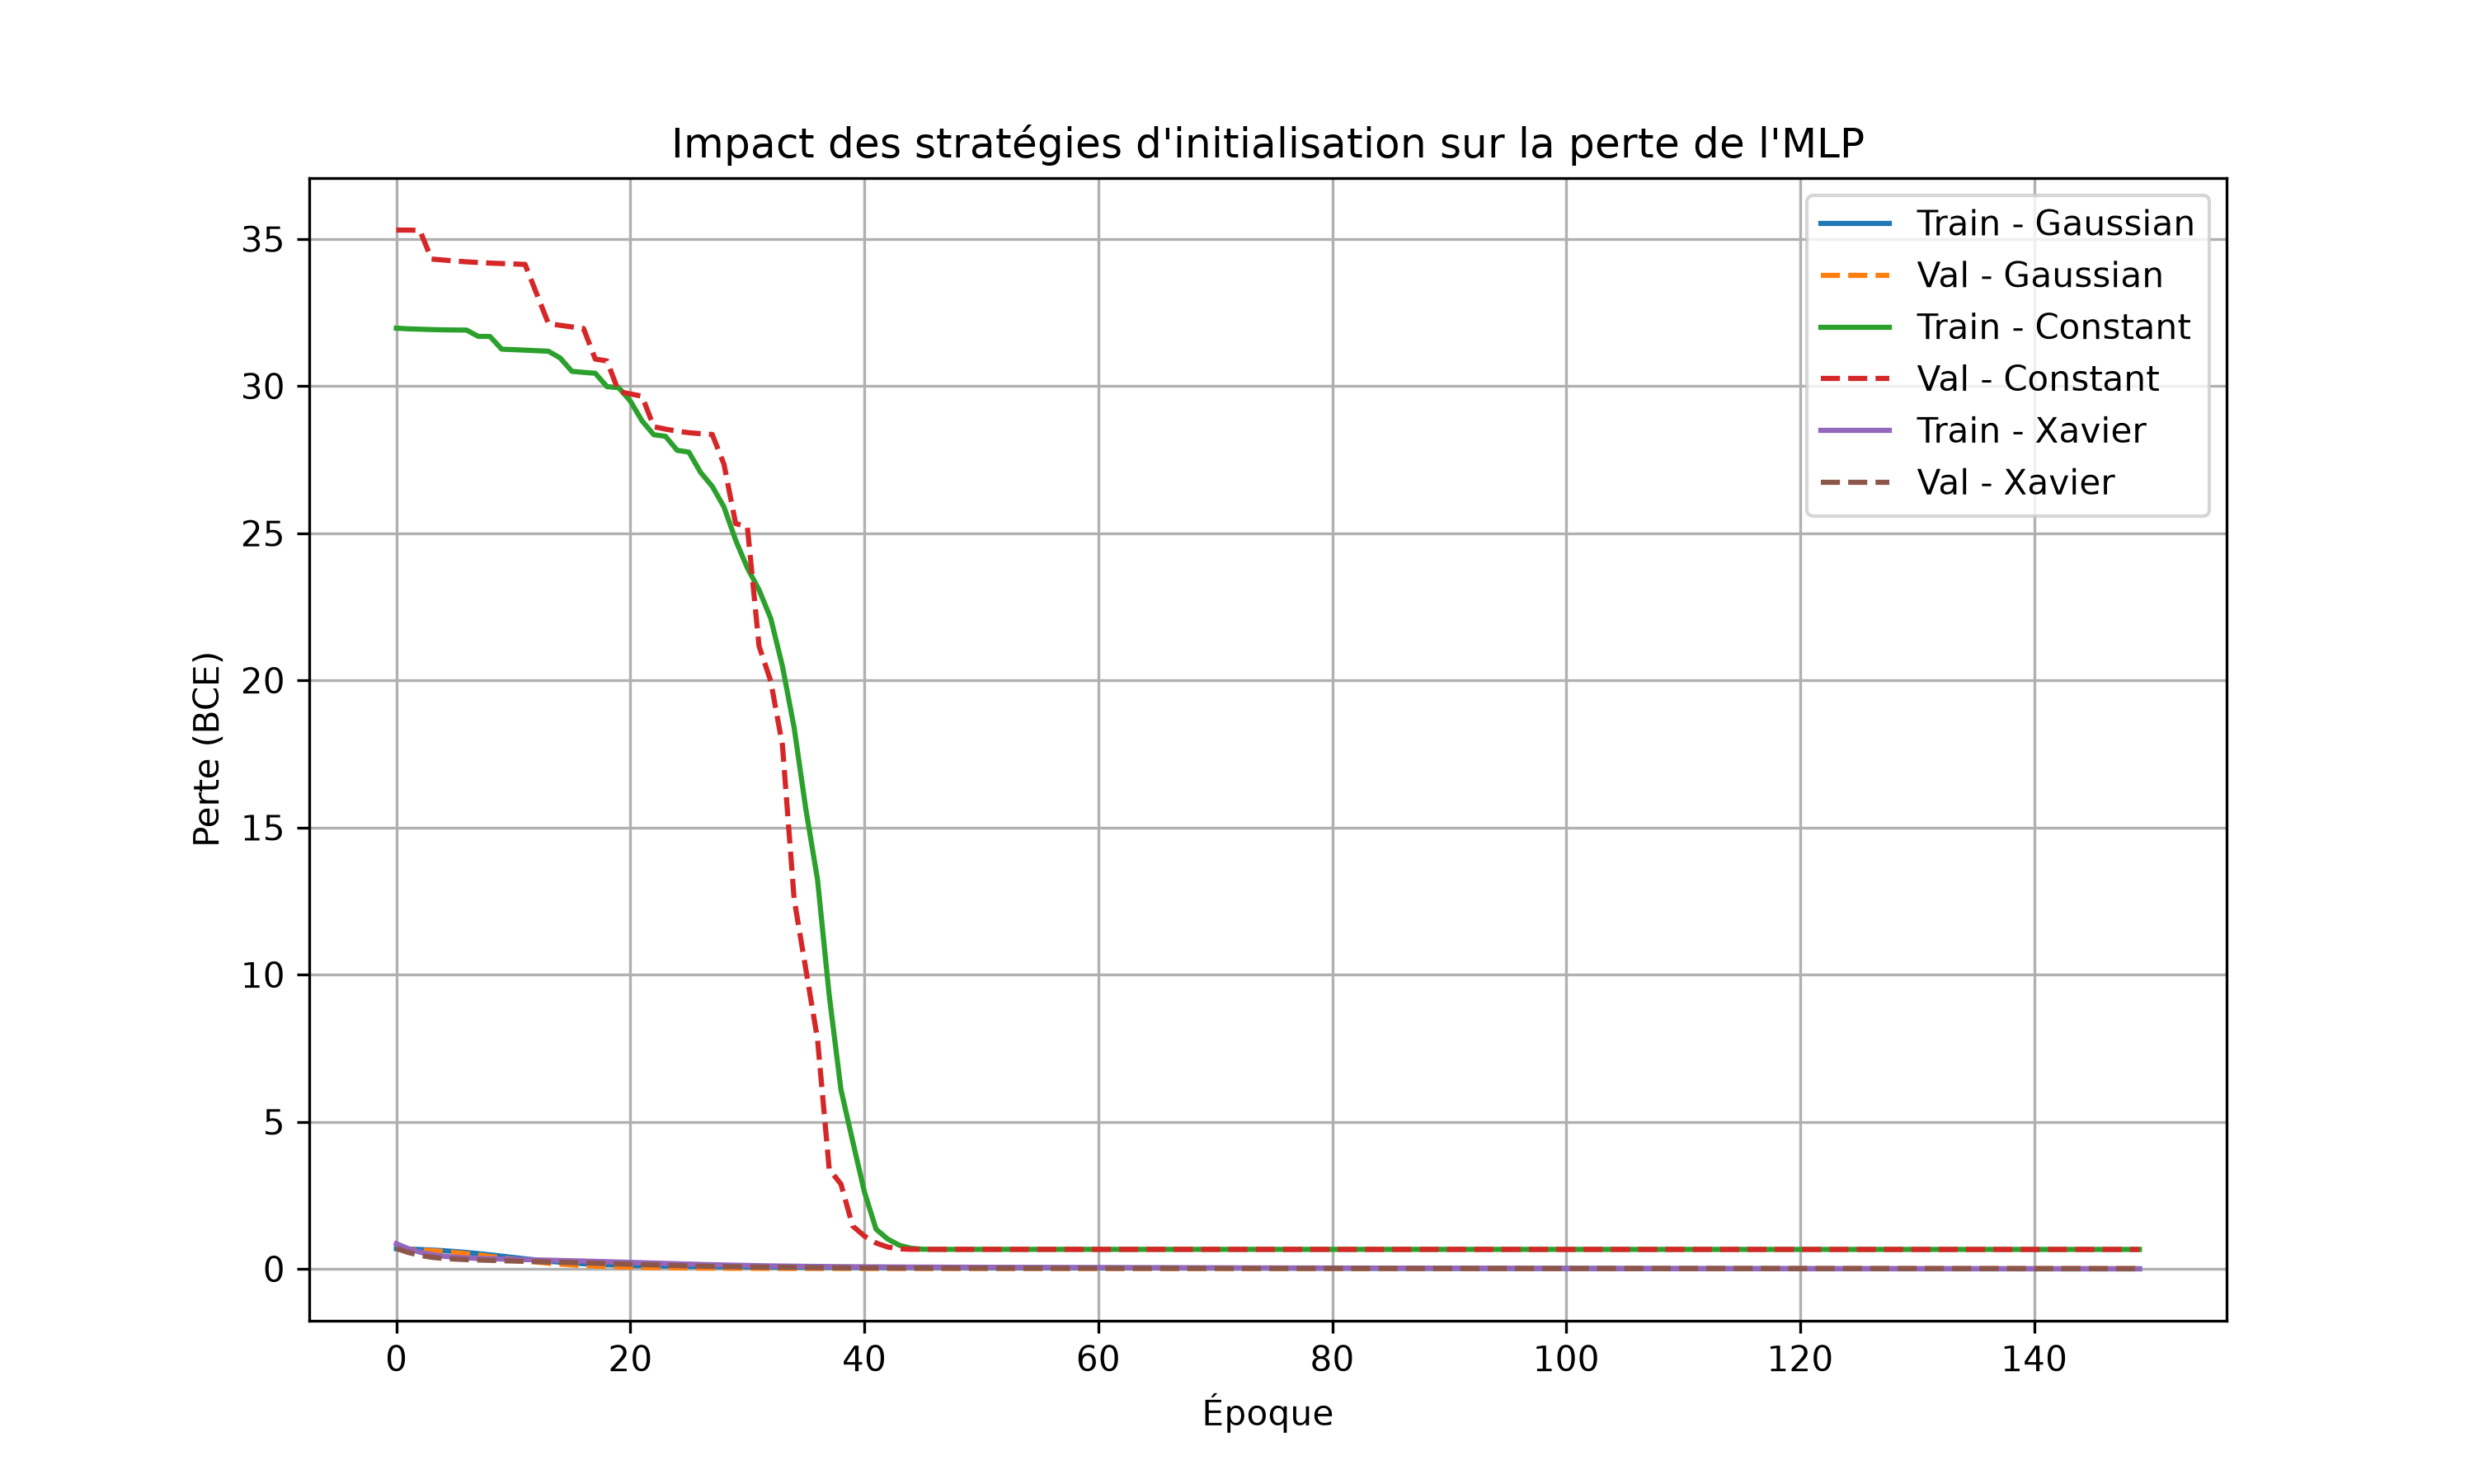

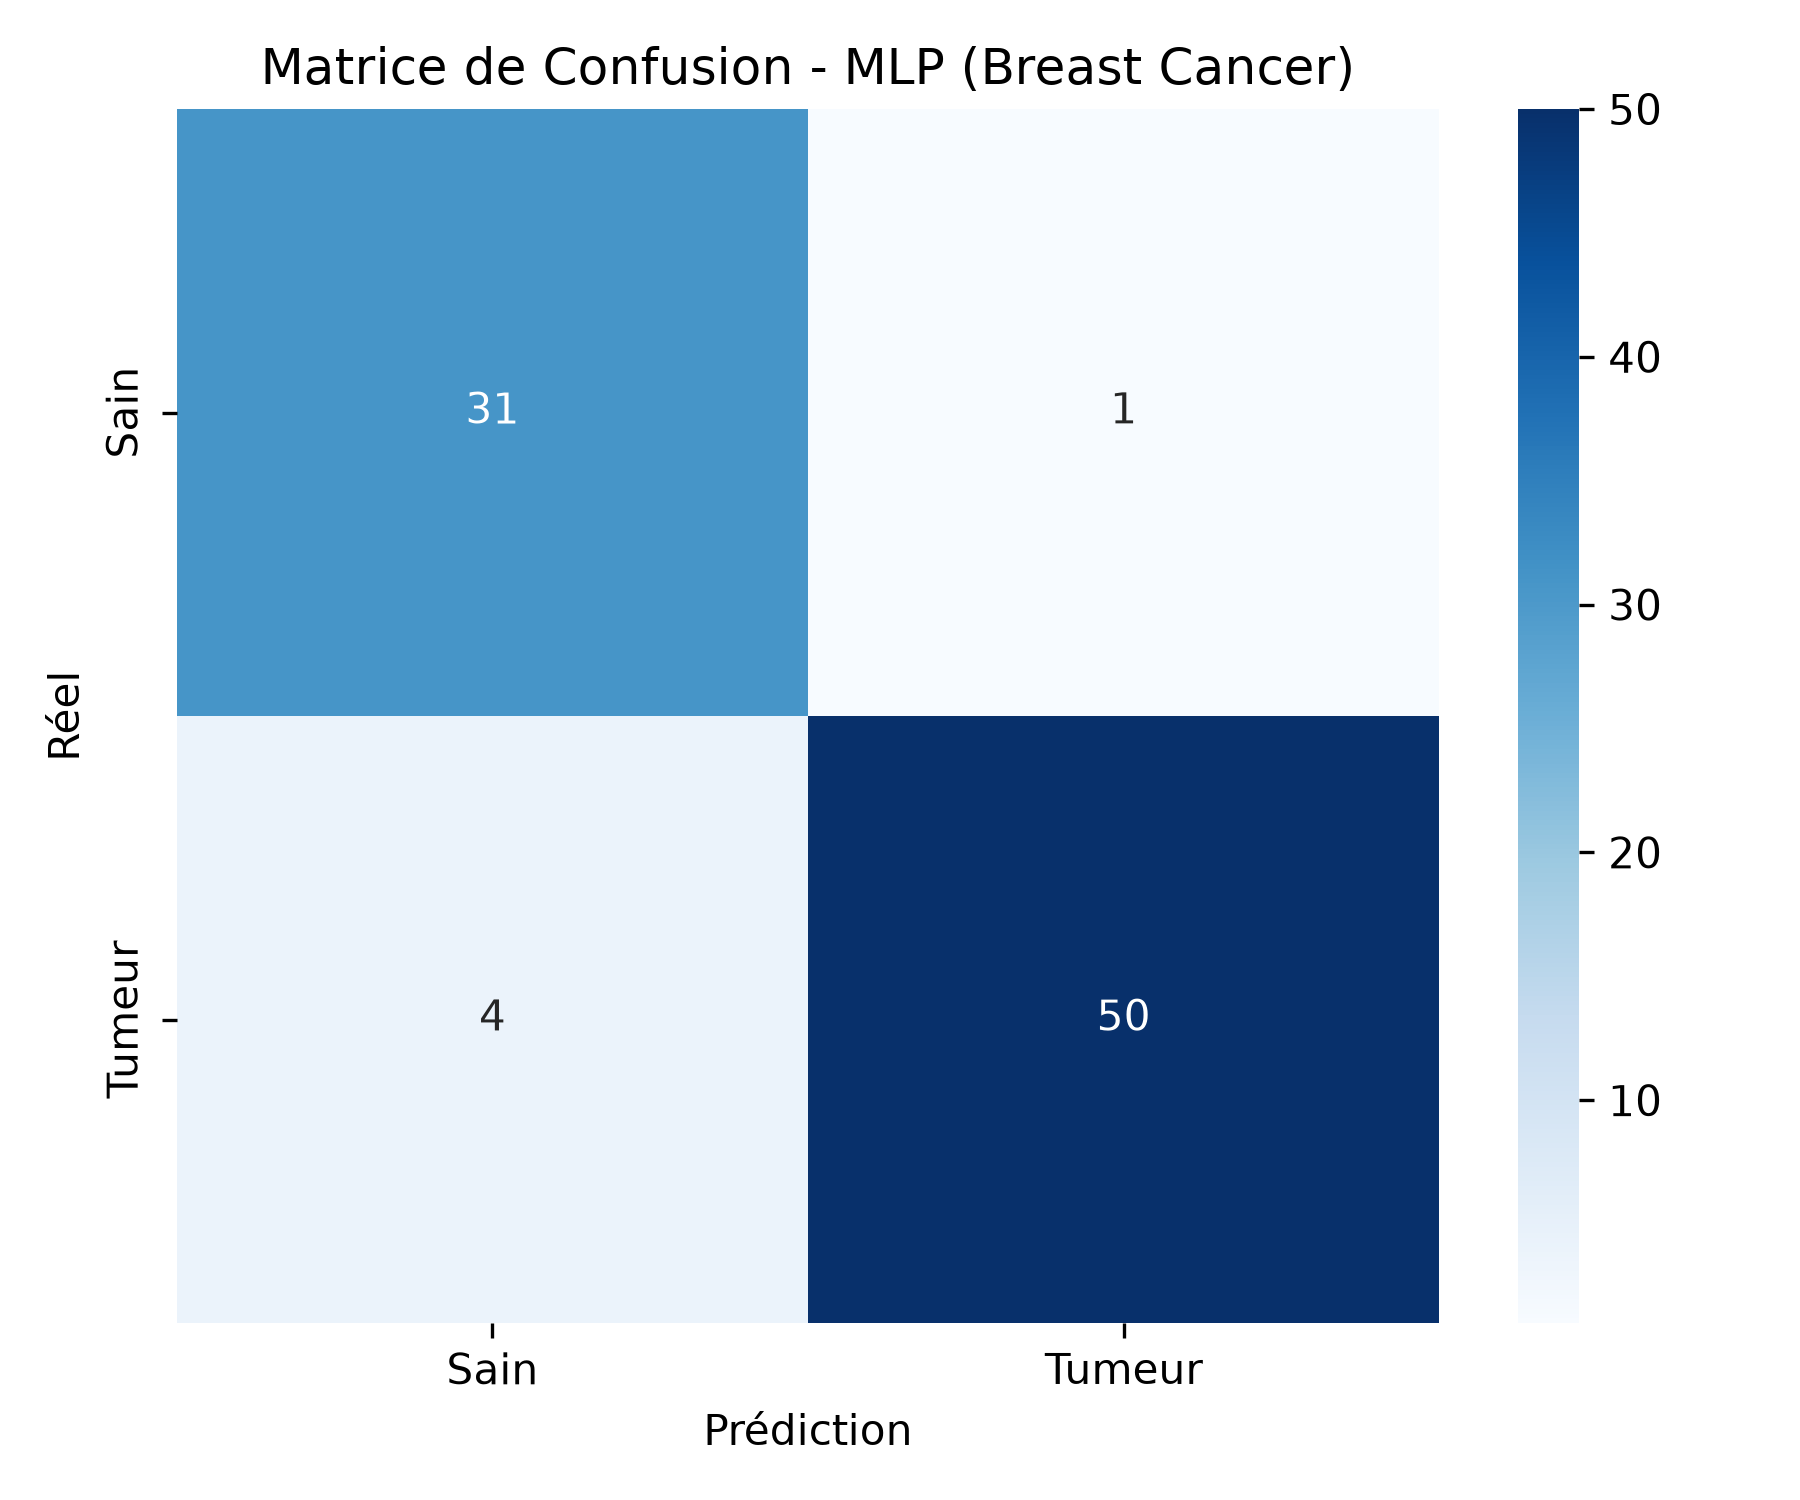

In [3]:
# Affichage des images enregistrées pour la Partie I
from IPython.display import Image, display
display(Image(filename='results/part1_loss.png'))
display(Image(filename='results/part1_confusion.png'))

## Partie II : CNN et Vision par Ordinateur
Cette partie vérifie nos implémentations manuelles de la corrélation croisée 2D, du max-pooling et de l'average-pooling (comparées avec PyTorch). Elle effectue ensuite des expériences comparatives d'architectures sur **Fashion-MNIST** et compare le CNN final avec un MLP simple.

In [4]:
from src.part2_cnn import run_part2
run_part2()

Périphérique d'exécution détecté pour la Partie II : cpu

PARTIE II : CNN ET VISION PAR ORDINATEUR

--- Vérification des implémentations manuelles (NumPy vs PyTorch) ---
Différence maximale corrélation croisée : 2.38e-07 (Succès: True)
Différence maximale Max-Pooling        : 0.00e+00 (Succès: True)
Différence maximale Average-Pooling    : 0.00e+00 (Succès: True)

Chargement de Fashion-MNIST...
Jeu de données réduit : 6000 images d'entraînement, 1000 images de test.

--- C. Expérimentations comparatives (Hyperparamètres du CNN) ---
Entraînement de Baseline (Padding=0, Stride=1, MaxPool)  | Paramètres : 20634   | Accuracy test finale : 81.70%
Entraînement de Padding=1                                | Paramètres : 29082   | Accuracy test finale : 84.50%
Entraînement de Stride=2                                 | Paramètres : 4506    | Accuracy test finale : 78.70%
Entraînement de AvgPool                                  | Paramètres : 20634   | Accuracy test finale : 80.30%
Entraînement d

### Visualisation des résultats de la Partie II

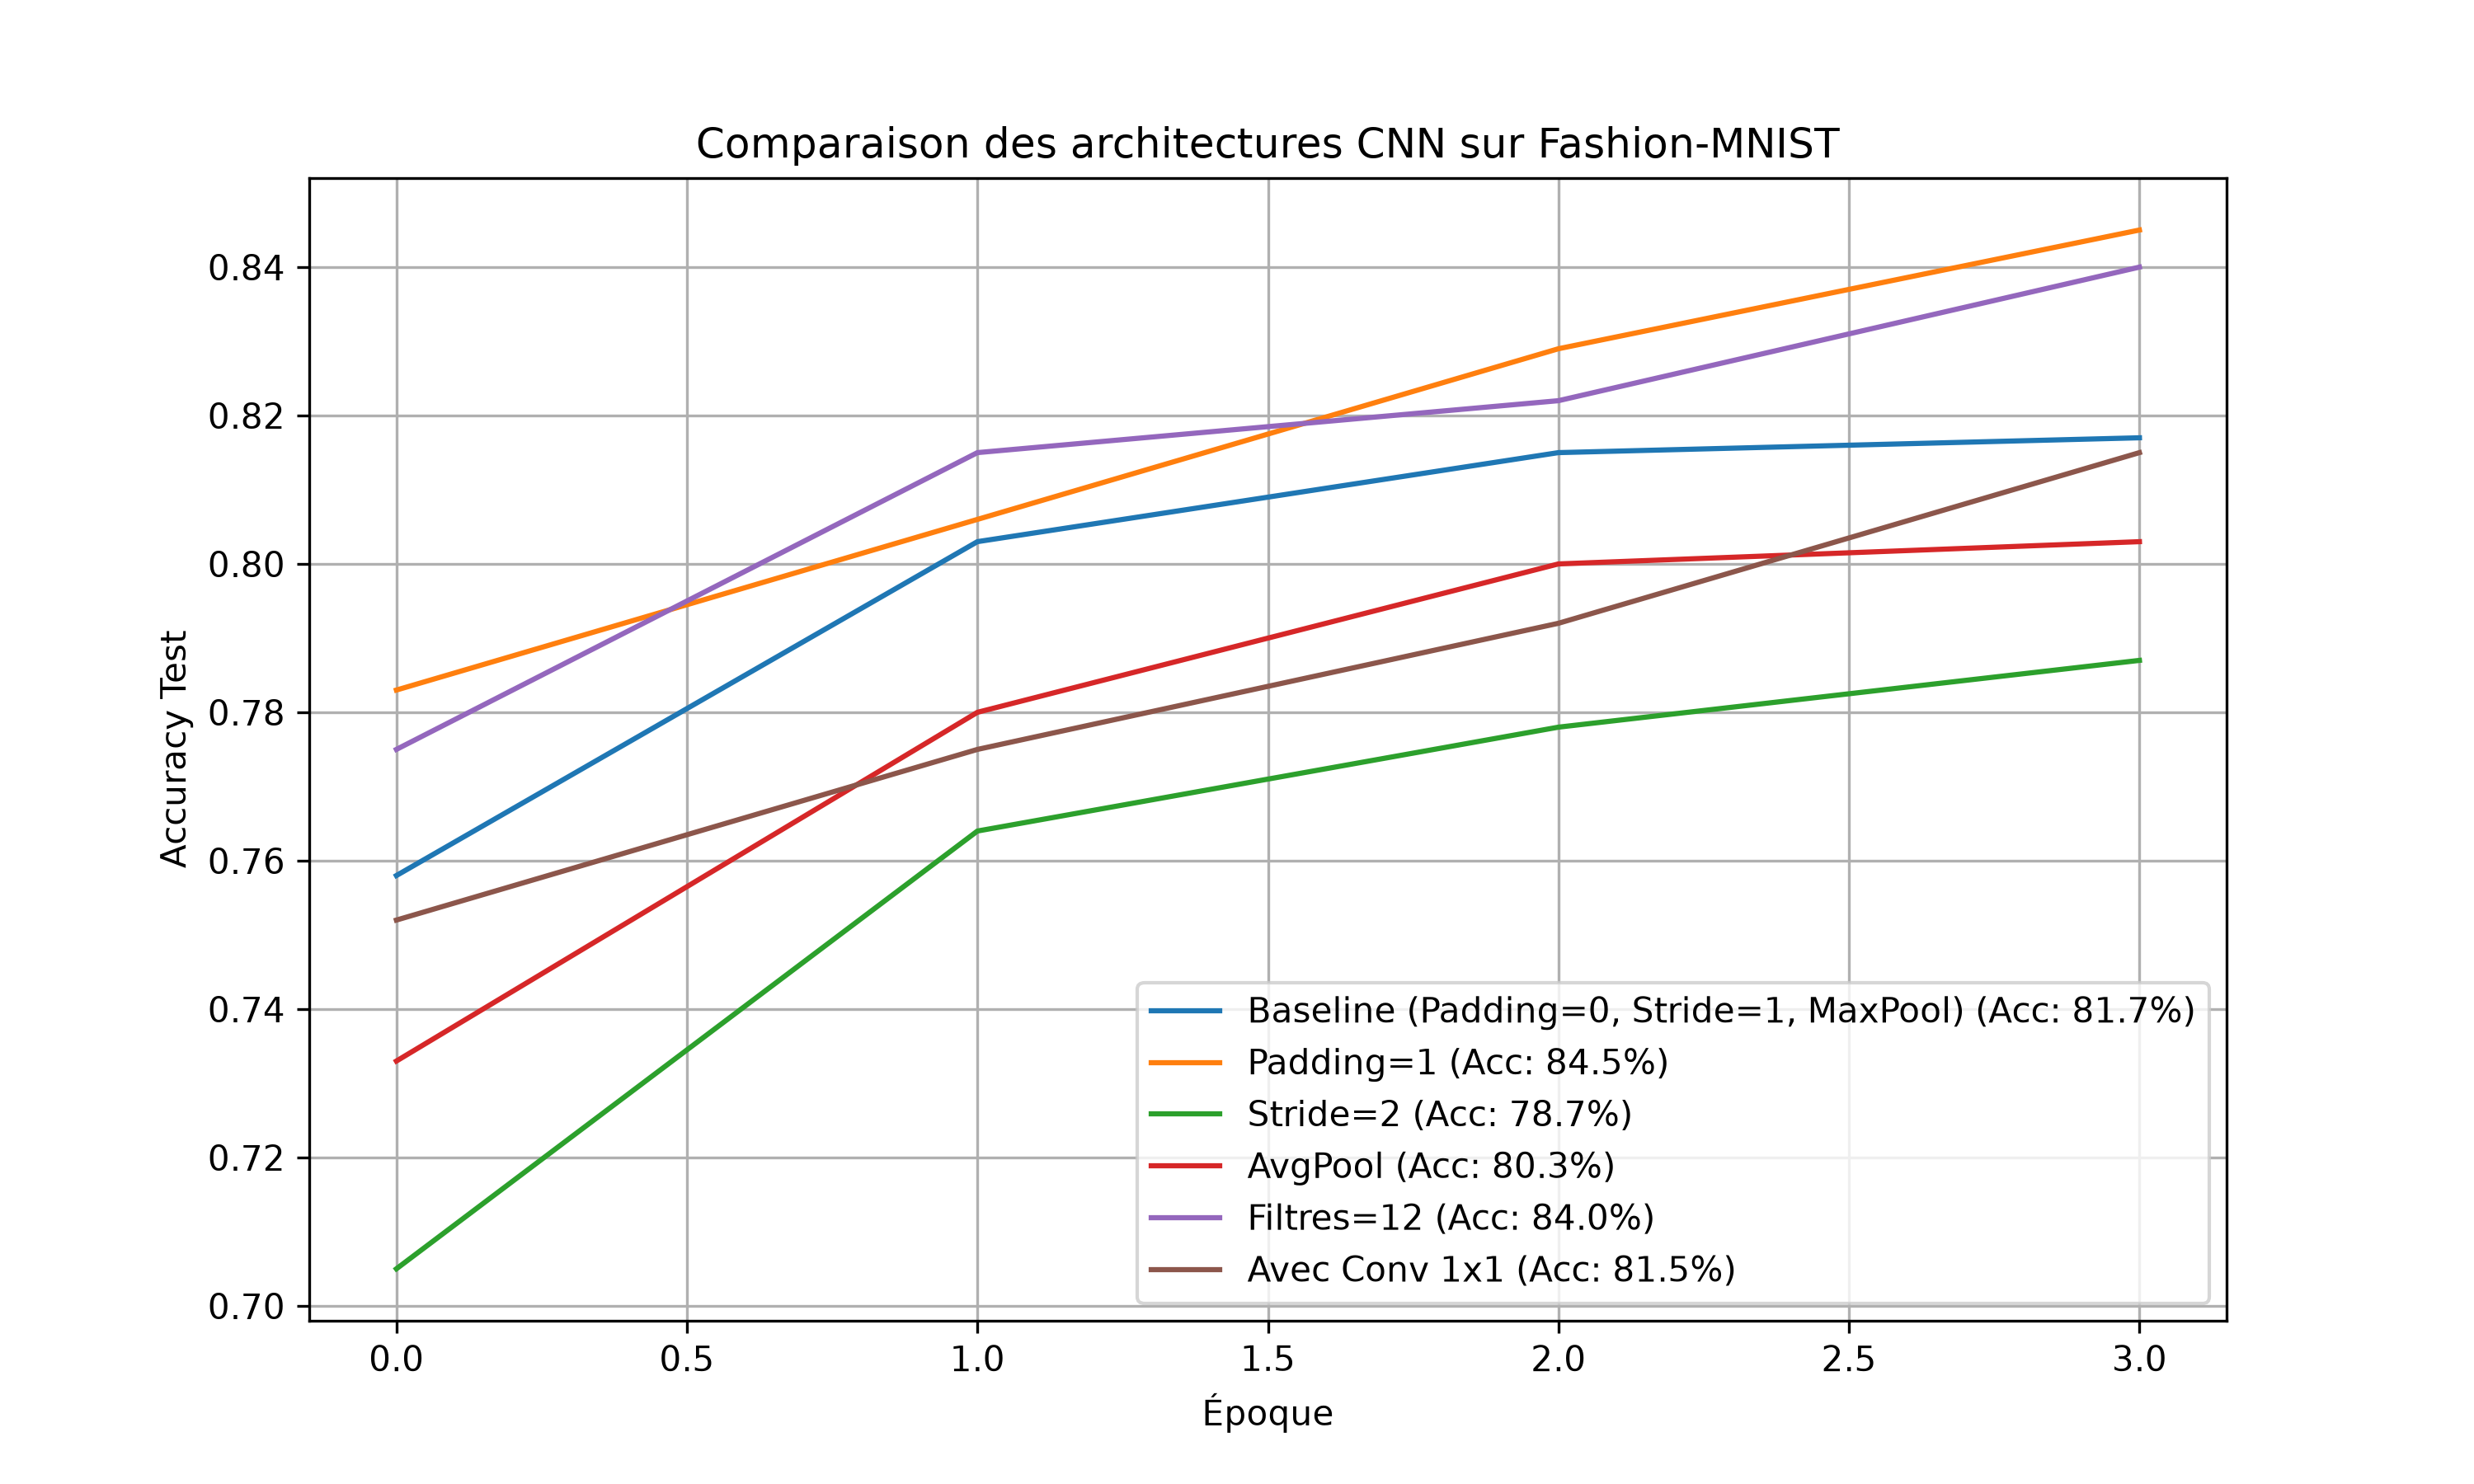

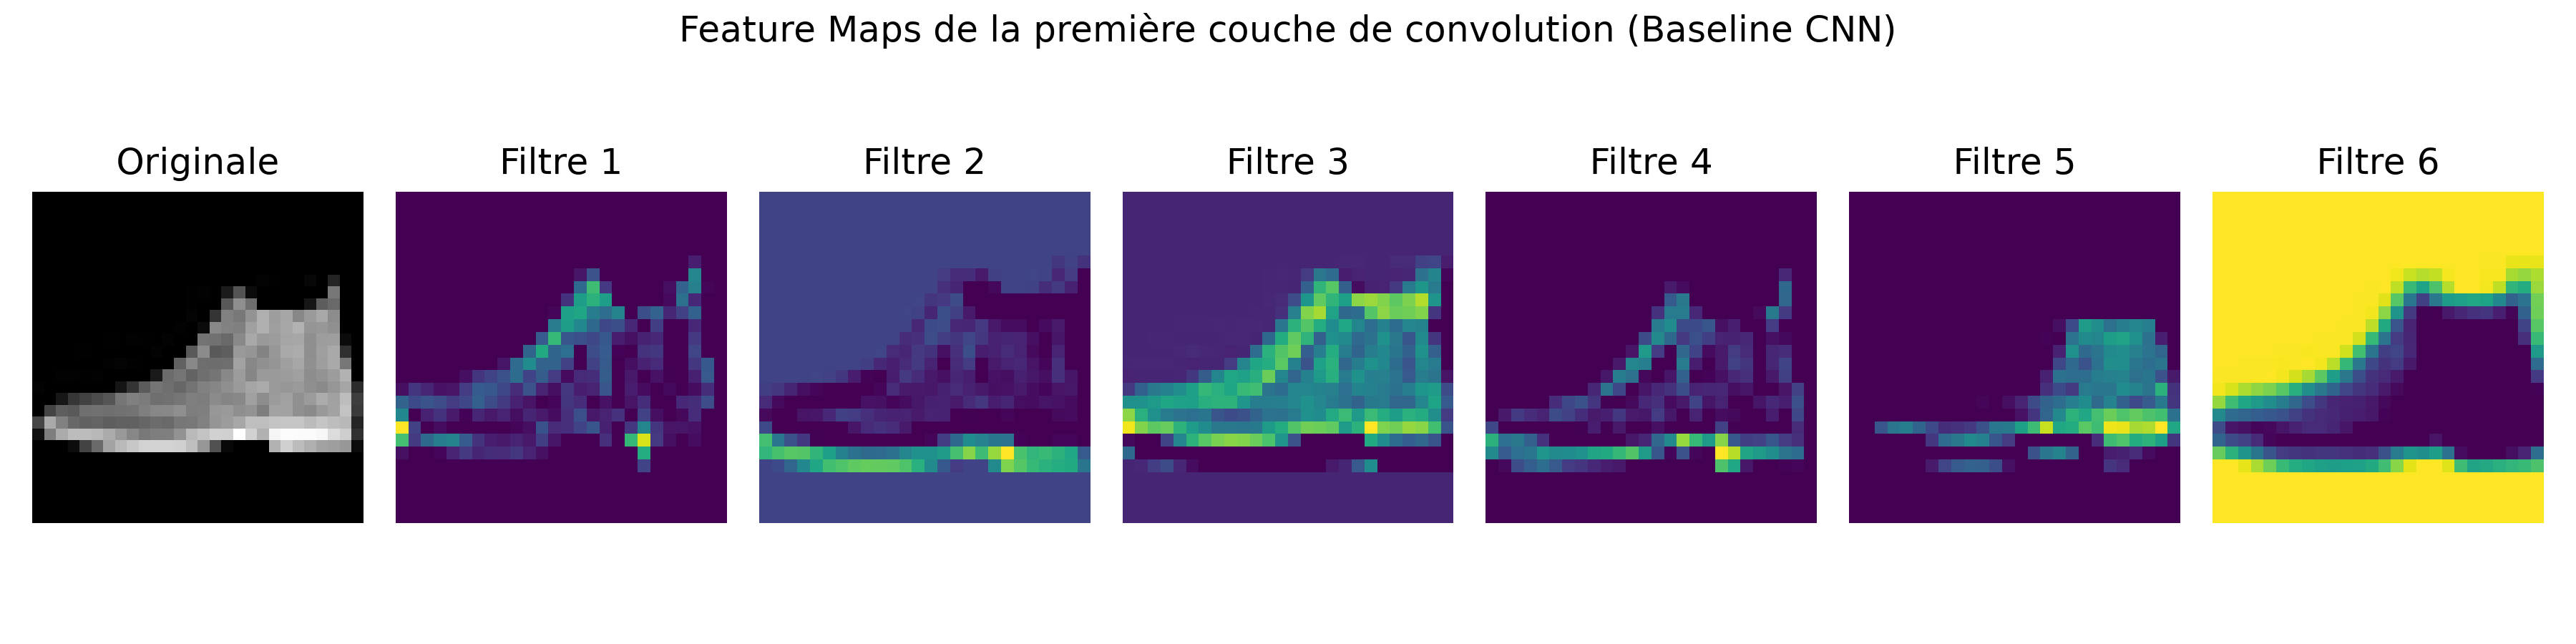

In [5]:
display(Image(filename='results/part2_comparison.png'))
display(Image(filename='results/part2_feature_maps.png'))

## Partie III : Modèles Séquentiels & Seq2Seq
Ici, nous illustrons l'impact du *Gradient Clipping* sur l'entraînement récurrent. Ensuite, nous entraînons un modèle de traduction automatique **Seq2Seq (Encoder-Decoder avec GRU)** sur un corpus parallèle Anglais-Français et comparons le décodage glouton (Greedy) au décodage par faisceau (Beam Search) en mesurant le score BLEU.

In [6]:
from src.part3_rnn import run_part3
run_part3()

Périphérique d'exécution détecté pour la Partie III : cpu

PARTIE III : RNN, LSTM, GRU ET SEQ2SEQ

--- Démonstration expérimentale du Gradient Clipping ---
Graphique du gradient clipping sauvegardé dans results/part3_grad_clipping.png
Jeu de données de traduction généré avec 438 paires de phrases dans data/english_french.txt
Taille du vocabulaire Anglais : 45
Taille du vocabulaire Français : 50

Entraînement du modèle Seq2Seq...
Époque 01 | Perte : 2.6494 | Perplexité : 14.15
Époque 02 | Perte : 1.3454 | Perplexité : 3.84
Époque 03 | Perte : 0.9949 | Perplexité : 2.70
Époque 04 | Perte : 0.7642 | Perplexité : 2.15
Époque 05 | Perte : 0.6382 | Perplexité : 1.89
Époque 06 | Perte : 0.5147 | Perplexité : 1.67
Époque 07 | Perte : 0.3405 | Perplexité : 1.41
Époque 08 | Perte : 0.2118 | Perplexité : 1.24
Époque 09 | Perte : 0.1090 | Perplexité : 1.12
Époque 10 | Perte : 0.0549 | Perplexité : 1.06
Époque 11 | Perte : 0.0341 | Perplexité : 1.03
Époque 12 | Perte : 0.0232 | Perplexité : 1.02
Ép

### Visualisation des résultats de la Partie III

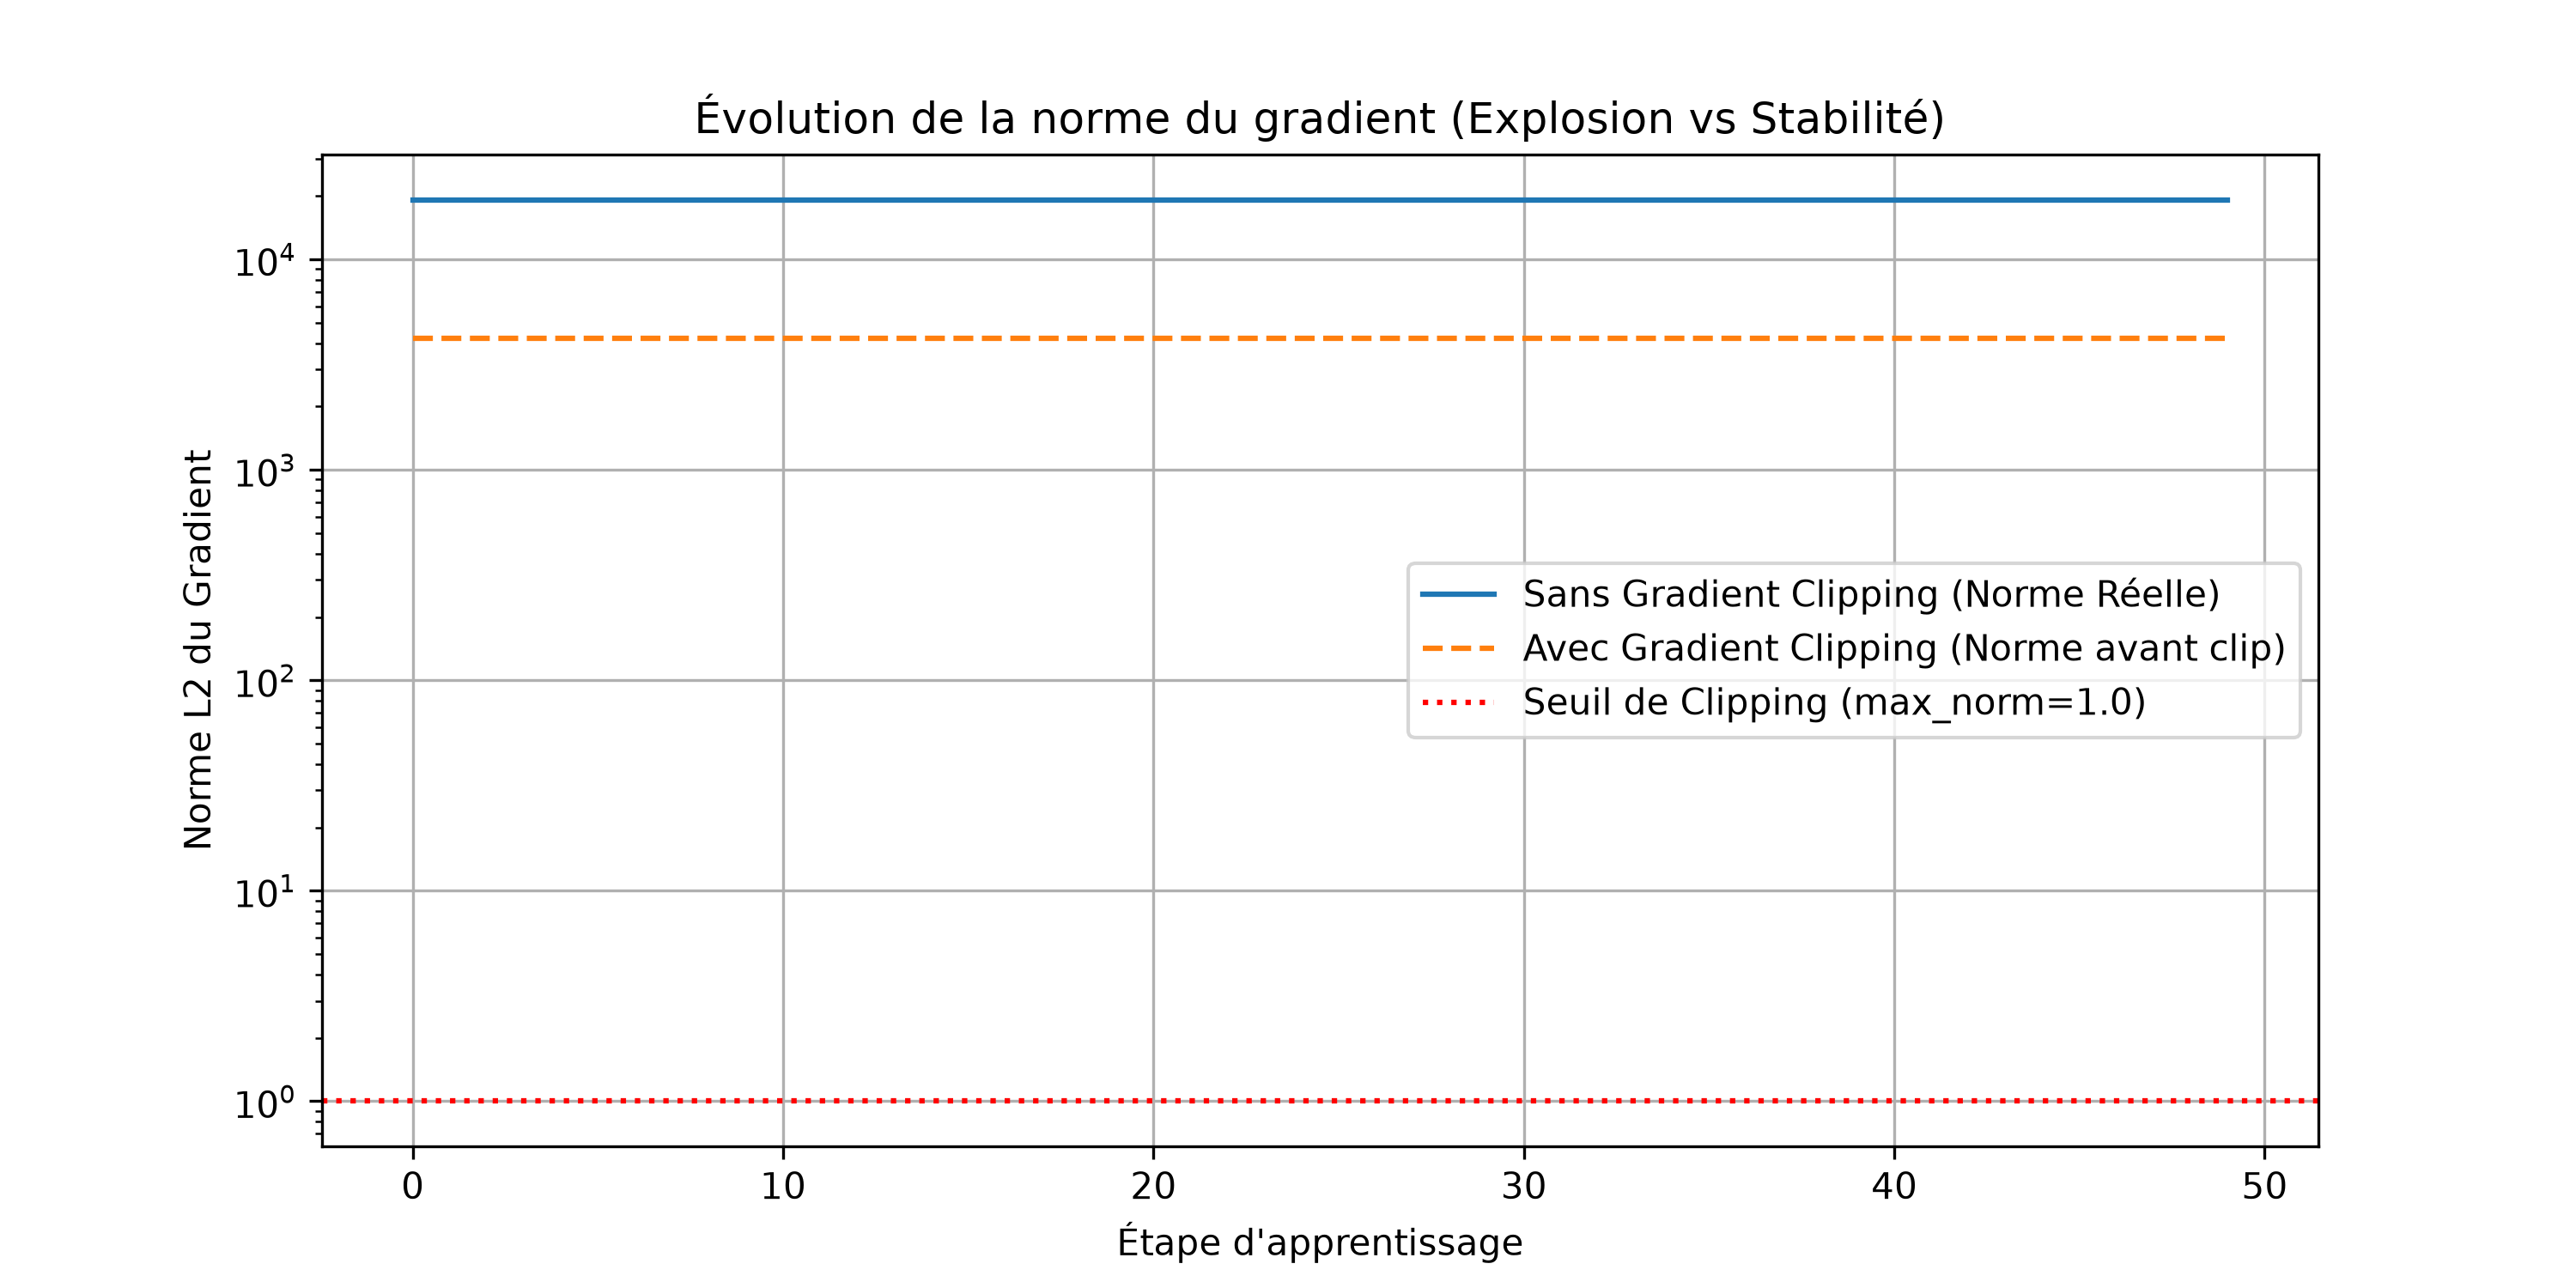

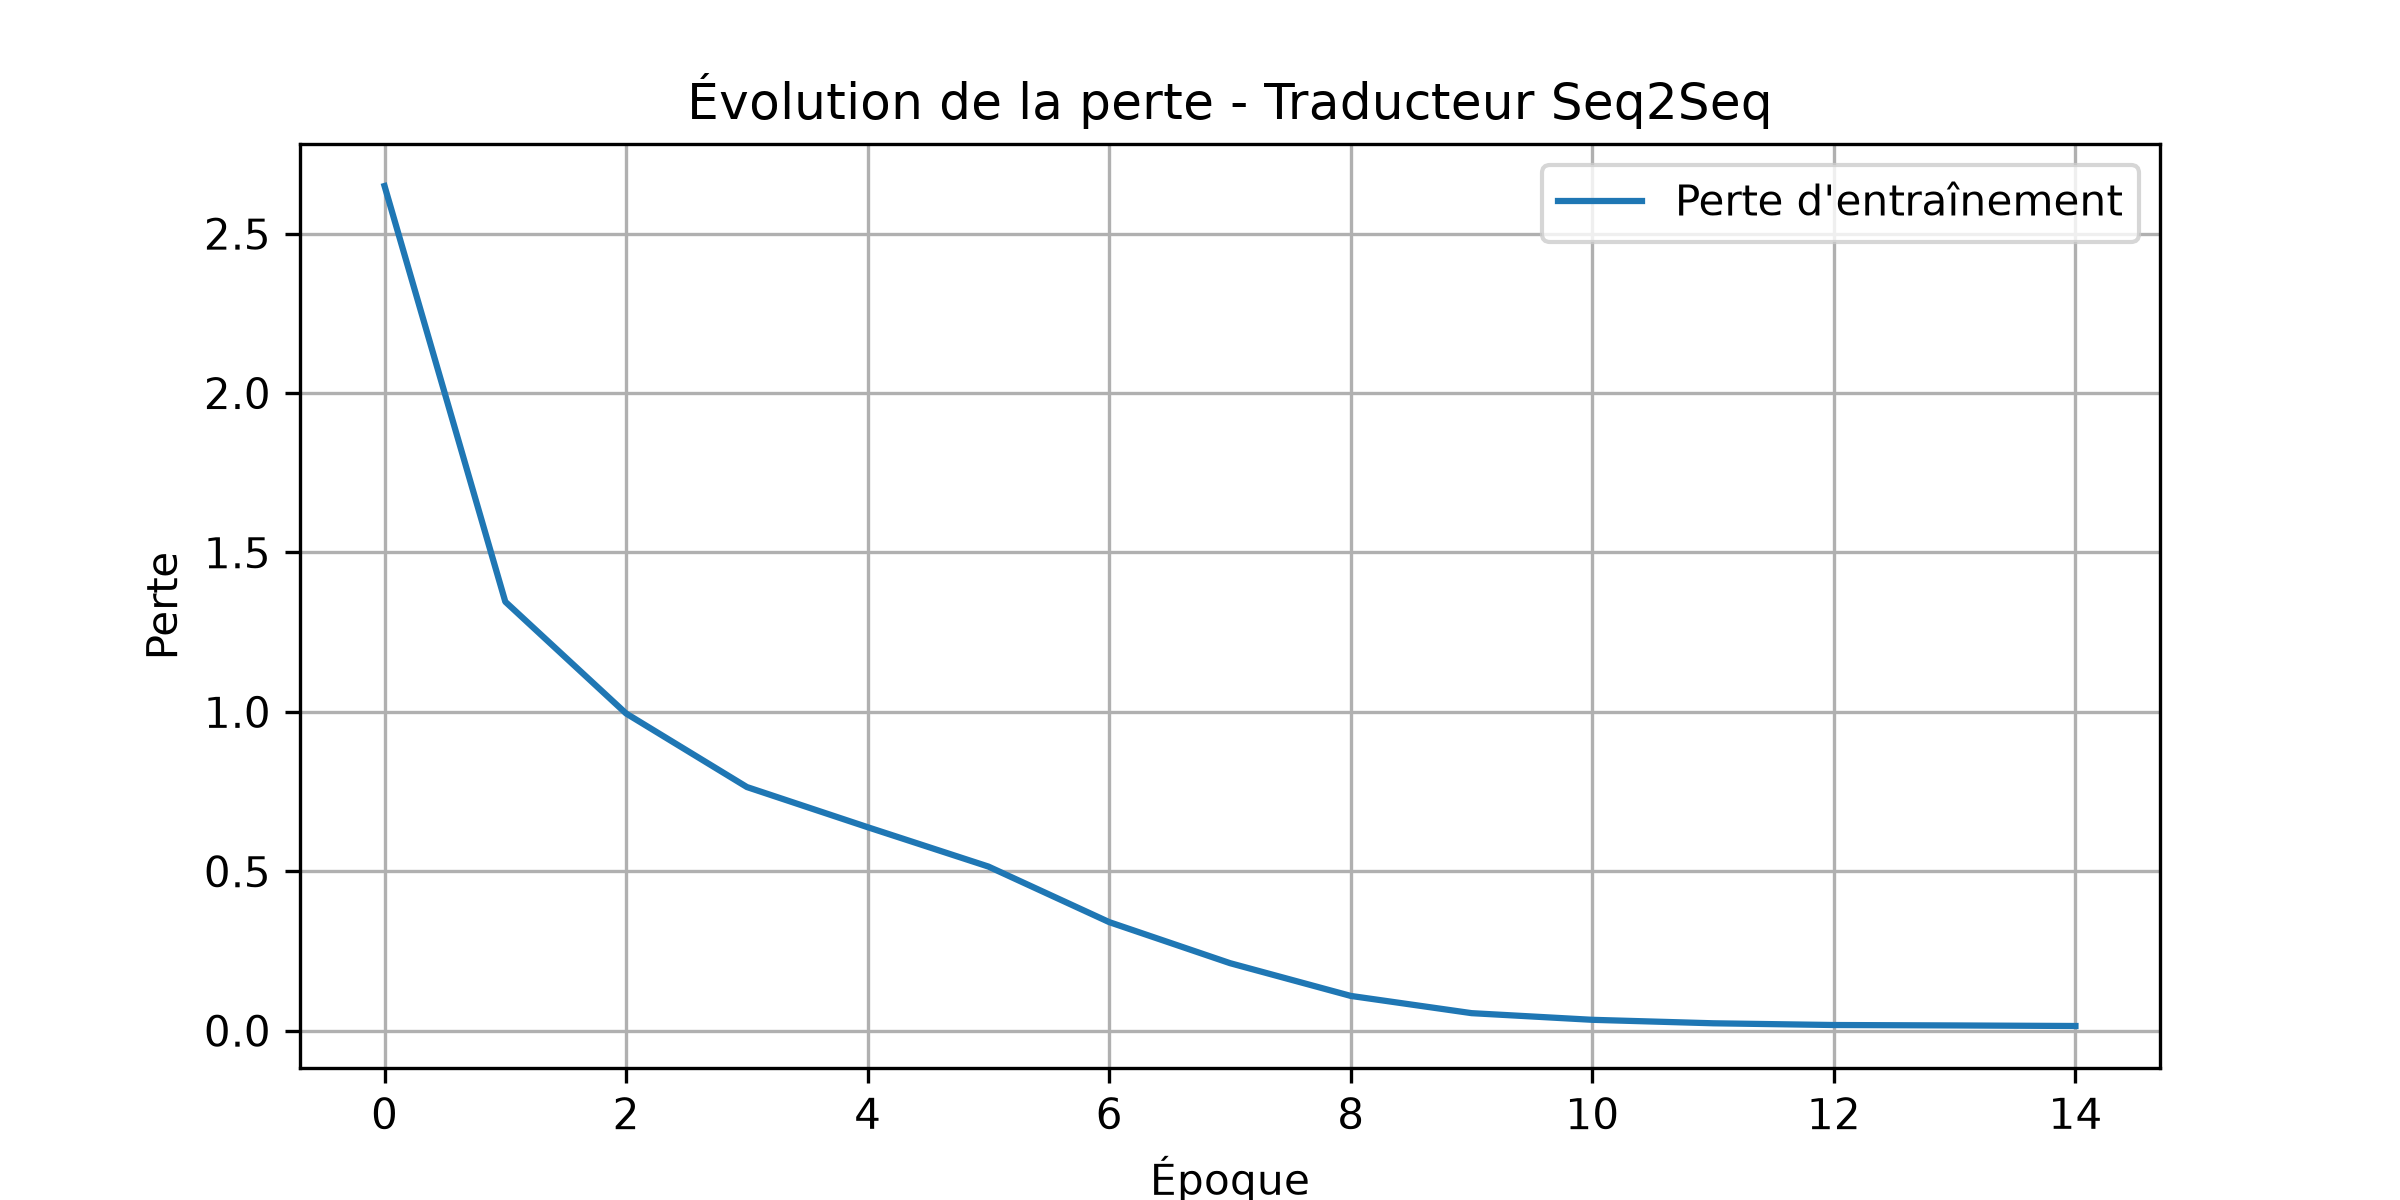

In [7]:
display(Image(filename='results/part3_grad_clipping.png'))
display(Image(filename='results/part3_loss.png'))